In [1]:
from datetime import datetime

from bluemath_tk.wrappers.schism.schism_wrapper import SchismHyCoFfEE

In [2]:
# load_cases (dataframe with historical + LHS_MDA cases)

import xarray as xr 

cases = xr.open_dataset('/lustre/geocean/WORK/users/Jared/HyCoFfEE/02_LHS_MDA/ALL_CASES_Santona.nc')
cases

<xarray.Dataset> Size: 106kB
Dimensions:   (index: 1200)
Coordinates:
  * index     (index) int64 10kB 0 1 2 3 4 5 6 ... 1194 1195 1196 1197 1198 1199
Data variables:
    Qp        (index) float64 10kB ...
    Qb        (index) float64 10kB ...
    Tp        (index) float64 10kB ...
    Tau_ss_d  (index) float64 10kB ...
    Sp        (index) float64 10kB ...
    Sb        (index) float64 10kB ...
    CM        (index) float64 10kB ...
    Tau       (index) float64 10kB ...
    wind      (index) float64 10kB ...
    wind_dir  (index) float64 10kB ...

In [3]:
cases = cases.sel(index =slice(0, 10))  # limit to 1000 cases for testing

In [4]:
import pandas as pd
import os.path as op

# Calculate the hydrogram parameters for the case.
p_hidro = '/home/grupos/geocean/ortizanguloj/Github-GeoOcean/BlueMath/methods/dynamical_downscaling/SchismExample/data/'
hidrograma = 'UH_SCS.xlsx'
hidro = pd.read_excel(op.join(p_hidro,hidrograma))
name_columns = hidro.columns
new_names = ['t', 'Q']
hidro.columns = new_names
new_data = {'t': 0, 'Q': 0}
new_df = pd.DataFrame([new_data])
hidro = pd.concat([new_df, hidro]).reset_index(drop=True)

In [5]:
fixed_parameters = {
    "start_year": 2000,
    "start_month": 2,
    "start_day": 1, 
    "start_hour": 0, 
    "utc_start": 8,
    "dt": 5,  # dt = 120 -> timestem (s) # nspool = 360; by default. It saves a data each nspool * dt = 30*120 = 3600 s = 1 h,
    "nspool": 360,
    "ihfskip": 518400,
    "nws": 1, # wind form .th
    "ics": 2,  # Coordinate option = 1: Cartesian; 2: lon/lat
    "hidro": hidro,
}

In [6]:
metamodel_parameters = {
    "Qp": cases.Qp.values.tolist(),  # List of Qp values for each case (m^3/s)  
    "Qb": cases.Qb.values.tolist(),  # List of Qb values for each case (m^3/s)
    "Sp": cases.Sp.values.tolist(),  # List of Sp values for each case (m)
    "Sb": cases.Sb.values.tolist(),  # List of Sb values for each case (m)
    "CM": cases.CM.values.tolist(),  # List of CM values for each case (m)
    "Tp": cases.Tp.values.tolist(),  # List of Tp values for each case (s)
    "Tau_ss_d": cases.Tau_ss_d.values.tolist(),  # List of Th values for each case (s)
    "Tau": cases.Tau.values.tolist(),  # List of Tau values for each case (s)
    "wind_magnitude": cases.wind.values.tolist(),  # Wind magnitudes (m/s) for each case
    "wind_direction": cases.wind_dir.values.tolist(),  # Wind directions (degrees) for each case
}

In [9]:
schism_wrapper = SchismHyCoFfEE(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir="CASES_HyCoFfEE",
)

2025-06-23 16:04:01,930 - SchismHyCoFfEE - WARNING - Parameter Qp is not in the default_parameters
2025-06-23 16:04:01,931 - SchismHyCoFfEE - WARNING - Parameter Qb is not in the default_parameters
2025-06-23 16:04:01,931 - SchismHyCoFfEE - WARNING - Parameter Sp is not in the default_parameters
2025-06-23 16:04:01,931 - SchismHyCoFfEE - WARNING - Parameter Sb is not in the default_parameters
2025-06-23 16:04:01,931 - SchismHyCoFfEE - WARNING - Parameter CM is not in the default_parameters
2025-06-23 16:04:01,932 - SchismHyCoFfEE - WARNING - Parameter Tp is not in the default_parameters
2025-06-23 16:04:01,932 - SchismHyCoFfEE - WARNING - Parameter Tau_ss_d is not in the default_parameters
2025-06-23 16:04:01,933 - SchismHyCoFfEE - WARNING - Parameter Tau is not in the default_parameters
2025-06-23 16:04:01,933 - SchismHyCoFfEE - WARNING - Parameter wind_magnitude is not in the default_parameters
2025-06-23 16:04:01,933 - SchismHyCoFfEE - WARNING - Parameter wind_direction is not in th

In [13]:
schism_wrapper.build_cases(mode="one_by_one")

9.07638888888889
6.368055555555555
9.159722222222221
9.993055555555555
7.951388888888889
8.993055555555555
9.368055555555555
8.993055555555555
9.284722222222221
8.993055555555555
7.826388888888889


In [ ]:
# launchSchism.sh

In [ ]:
# ncases = len(df_v.Qp) 

# for n in range(n_subset): #range(ncases):
     
#     # Crear un nuevo nombre para la carpeta copiada
#     folder_name = 'Case_test'
#     new_folder_name = f"{folder_name}_{n+1}" 

#     new_folder_path = os.path.join(p_out, new_folder_name)
#     if not os.path.isdir(new_folder_path): os.makedirs(new_folder_path)

#     qb = df_v.iloc[n].Qb
#     qp = df_v.iloc[n].Qp
#     tp = df_v.iloc[n].Tp

#     #Puede ser que tau(ss-d) sea negativo pero Tp sea tan pequeño que las 24 horas del surge empiecen antes que el hidrograma de caudal
#     time0=df_v.iloc[n]['Tp'] + abs(df_v.iloc[n]['Tau_ss_d']) - 24

#     # hidrograma SCS
#     hidro_Qp = hidro.Q*(qp-qb) + qb
#     if (df_v.iloc[n]['Tau_ss_d']<=0 and time0>=0 and df_v.iloc[n]['Tp']!=0):   #el hidrograma marca el inicio del tiempo
#        hidro_hours = hidro.t.values*tp 
#     else:
#         if (df_v.iloc[n]['Tau_ss_d']<=0 and time0<0 and df_v.iloc[n]['Tp']!=0):
#             hidro_hours = hidro.t.values*tp + abs(time0)   #el storm surge marca el inicio y hay que sumar el Tau con respecto al surge
#         else:  
#             if df_v.iloc[n]['Tau_ss_d']>0:
#                 t0 = 24 - (df_v.iloc[n]['Tp'] - df_v.iloc[n]['Tau_ss_d']) 
#                 hidro_hours = hidro.t.values*tp + t0   #el storm surge marca el inicio y hay que sumar el Tau con respecto al surge
#             else:  #el desfase es cero 
#                 if df_v.iloc[n]['Tp']==0:  #el tiempo de concentración también, con lo que se supone que el caudal es constante e igual al base
#                     hidro_hours = np.arange(0,49,1)
#                     hidro_Qp = np.ones(len(hidro_hours))*qp
               
#     hidro_seg = hidro_hours*3600

#     #duración teniendo en cuenta los desfases entre picos de caudal y storm surge
#     #en el caso de Tau(ss-d) < 0 y Tp suficientemente grande para que el hidrograma de caudal marque el inicio
#     timef = df_v.iloc[n]['Tp'] + abs(df_v.iloc[n]['Tau_ss_d']) + 24










#     #AT
#     # Creamos un array con los valores de tiempo (48 horas)
#     int_min = 5*60

#     if (timef>np.max(hidro_hours) and df_v.iloc[n]['Tau_ss_d']<0 and time0>0): #añadido nuevo el time0>0
#         t = np.arange(0, timef*3600, int_min)
#         #interpolamos caudal a esa resolución temporal
#         f = interp1d(hidro_seg, hidro_Qp, kind='linear')
#         t2 = np.arange(0, np.max(hidro_seg), int_min)
#         hidro_Qp_5_1 = f(t2)
#         t3 = np.max(t) - np.max(t2)
#         hidro_Qp_5_2 = np.zeros(int(t3/int_min))+hidro_Qp.values[-1]
#         hidro_Qp_5 = np.hstack((hidro_Qp_5_1,hidro_Qp_5_2))
#     else:
#         if (hidro_hours[-1]<48 and df_v.iloc[n]['Tau_ss_d']<0  and time0>0):  #añadido nuevo el time0>0
#             t = np.arange(0, 48*3600, int_min)
#             #interpolamos caudal a esa resolución temporal
#             f = interp1d(hidro_seg, hidro_Qp, kind='linear')
#             t2 = np.arange(0, np.max(hidro_seg), int_min)
#             hidro_Qp_5_1 = f(t2)
#             t3 = np.max(t) - np.max(t2)
#             hidro_Qp_5_2 = np.zeros(int(t3/int_min))+hidro_Qp.values[-1]
#             hidro_Qp_5 = np.hstack((hidro_Qp_5_1,hidro_Qp_5_2))
#         else:
#             if (df_v.iloc[n]['Tau_ss_d']<=0 and time0<0 and df_v.iloc[n]['Tp']!=0 and hidro_hours[-1]>48):
#                 t = np.arange(0, np.max(hidro_seg), int_min)
#                 hidro_Qp_5_1 = np.full(int(abs(time0*3600/int_min)),qb)
#                 f = interp1d(hidro_seg, hidro_Qp, kind='linear')                    
#                 t2 = np.arange(np.min(hidro_seg),np.max(hidro_seg), int_min)        
#                 hidro_Qp_5_2 = f(t2)
#                 hidro_Qp_5 = np.hstack((hidro_Qp_5_1,hidro_Qp_5_2))
#             else:
#                 if (df_v.iloc[n]['Tau_ss_d']<=0 and time0<0 and df_v.iloc[n]['Tp']!=0 and hidro_hours[-1]<48):
#                     t = np.arange(0, 48*3600, int_min)
#                     hidro_Qp_5_1 = np.full(int(abs(time0*3600/int_min)),qb)
#                     f = interp1d(hidro_seg, hidro_Qp, kind='linear')                    
#                     t2 = np.arange(np.min(hidro_seg),np.max(hidro_seg), int_min)        
#                     hidro_Qp_5_2 = f(t2)
#                     time_left = 48 - hidro_hours[-1]
#                     hidro_Qp_5_3 = np.full(int(abs(time_left*3600/int_min)),qb)
#                     hidro_Qp_5 = np.hstack((hidro_Qp_5_1,hidro_Qp_5_2,hidro_Qp_5_3))
#                 else: 
#                     if hidro_hours[-1]<48:
#                         t0 = 24 - (df_v.iloc[n]['Tp'] - df_v.iloc[n]['Tau_ss_d']) 
#                         #timef2 = t0 + np.max()
#                         t = np.arange(0, 48*3600, int_min)
#                         hidro_Qp_5_0 = np.zeros(int(t0*3600/int_min))+qb
#                         #interpolamos caudal a esa resolución temporal
#                         f = interp1d(hidro_seg, hidro_Qp, kind='linear')
#                         t2 = np.arange(np.min(hidro_seg),np.max(hidro_seg), int_min)
#                         hidro_Qp_5_1 = f(t2)
#                         t3 = np.max(t) - np.max(t2)
#                         hidro_Qp_5_2 = np.zeros(int(t3/int_min))+qb
#                         hidro_Qp_5 = np.hstack((hidro_Qp_5_0,hidro_Qp_5_1,hidro_Qp_5_2))
#                     else:
#                         t = np.arange(0, np.max(hidro_seg), int_min)
#                         #interpolamos caudal a esa resolución temporal
#                         f = interp1d(hidro_seg, hidro_Qp, kind='linear')
#                         if df_v.iloc[n]['Tau_ss_d']>0:
#                             t0 = 24 - (df_v.iloc[n]['Tp'] - df_v.iloc[n]['Tau_ss_d']) 
#                             #hidro_Qp_5_1 = np.full(int(df_v.iloc[n]['Tau_ss_d']*3600/5),qb)
#                             hidro_Qp_5_1 = np.full(int(t0*3600/int_min),qb)
#                             t2 = np.arange(np.min(hidro_seg),np.max(hidro_seg), int_min)
#                             hidro_Qp_5_2 = f(t2)
#                             hidro_Qp_5 = np.hstack((hidro_Qp_5_1,hidro_Qp_5_2))
#                         else:
#                             hidro_Qp_5 = f(t)   #el hidrograma abarca todo el tiempo

   
#     #Tau (desfase de la pleamar con respecto al pico de caudal Qp - en horas)
#     tau = df_v.iloc[n]['Tau']

#     #AT
#     at = np.sin(np.pi/2 + np.pi*tau/6 + 2*np.pi*t/(12*3600))* df_v.iloc[n]['CM']/2
    
#     #Storm surge
#     time0=df_v.iloc[n]['Tp'] + abs(df_v.iloc[n]['Tau_ss_d']) - 24 
#     if df_v.iloc[n]['Tau_ss_d']<0 and (time0>0):   #el hidrograma marca el inicio del tiempo
#         #desde el inicio del hidrograma hasta que empieza el pico, el valor del surge es el base
#         #time0=df_v.iloc[n]['Tp'] + abs(df_v.iloc[n]['Tau_ss_d']) - 24 
#         ss0 = np.full(int(time0*3600/int_min),df_v.iloc[n]['Sb'])
#         #24 horas hasta el pico
#         ss1 = np.linspace(df_v.iloc[n]['Sb'], df_v.iloc[n]['Sp'], int(24*3600/int_min))
#         #24 horas después del pico
#         ss2 = np.linspace(df_v.iloc[n]['Sp'], df_v.iloc[n]['Sb'], int(24*3600/int_min))
#         #lo que quede hasta el final del hidrograma
#         timef2 = df_v.iloc[n]['Tp'] + abs(df_v.iloc[n]['Tau_ss_d']) + 24
#         time_final = np.max(t) - (timef2*3600-int_min)
#         ss3 = np.full(int(time_final/int_min),df_v.iloc[n]['Sb'])
#         ss = np.hstack((ss0,ss1,ss2,ss3))
    
#     else:  

#         #storm surge marca el inicio del tiempo, surge centrado en las primeras 48 horas
#         ss1 = np.linspace(df_v.iloc[n]['Sb'], df_v.iloc[n]['Sp'], int(24*3600/int_min))
#         ss2 = np.linspace(df_v.iloc[n]['Sp'], df_v.iloc[n]['Sb'], int(24*3600/int_min))
#         timet = time0+hidro_hours[-1]
#         if timet<48:
#            ss = np.hstack((ss1,ss2))
#         else:
#             #a partir de las 48 horas, el surge tiene el valor del base
#            time_final = np.max(t) - (48*3600-int_min)
#            ss3 = np.full(int(time_final/int_min),df_v.iloc[n]['Sb'])
#            ss = np.hstack((ss1,ss2,ss3))


#     t_inicial = np.arange(0, 4*24*3600, int_min)
#     ss_inicial = np.zeros(len(t_inicial)) + df_v.iloc[n]['Sb']
#     at_inicial = np.sin(np.pi/2 + np.pi*tau/6 + 2*np.pi*t_inicial/(12*3600))* df_v.iloc[n]['CM']/2
#     q_inicial = np.zeros(len(t_inicial)) - qb

#     t_series = np.hstack((t_inicial,t_inicial[-1]+t))
#     at_series = np.hstack((at_inicial,at))
#     if len(ss)<len(at):
#         ss4=np.full(int(len(at)-len(ss)),ss[-1])
#         ss = np.hstack((ss,ss4))
#         ss_series = np.hstack((ss_inicial,ss))
#     else: 
#         ss_series = np.hstack((ss_inicial,ss)) 

#     if len(hidro_Qp_5)<len(at):
#         qq4=np.full(int(len(at)-len(hidro_Qp_5)),-hidro_Qp_5[-1])
#         hidro_Qp_5 = np.hstack((hidro_Qp_5,qq4))
#         qq_series = np.hstack((q_inicial,-hidro_Qp_5))
#     else: 
#         qq_series = np.hstack((q_inicial,-hidro_Qp_5))

#     AT_SS_series = ss_series + at_series

#     #astronomical tide (aunque no lo pide SCHISM lo guardamos para pintar resultados)
#     at_file = op.join(new_folder_path,'at.th')
#     input_at = np.vstack((t_series, at_series)).T
#     with open(at_file, 'w') as file:
#         for line in input_at:
#             line_towrite=' '.join(map(str,line))
#             file.write(line_towrite+ '\n')

#     #storm surge (aunque no lo pide SCHISM lo guardamos para pintar resultados)
#     ss_file = op.join(new_folder_path,'ss.th')
#     input_ss = np.vstack((t_series, ss_series)).T
#     with open(ss_file, 'w') as file:
#         for line in input_ss:
#             line_towrite=' '.join(map(str,line))
#             file.write(line_towrite+ '\n')

#     elev_file = op.join(new_folder_path,'elev.th')
#     input_elev = np.vstack((t_series, AT_SS_series)).T
#     with open(elev_file, 'w') as file:
#         for line in input_elev:
#             line_towrite=' '.join(map(str,line))
#             file.write(line_towrite+ '\n')
   
#     flux_file = op.join(new_folder_path,'flux.th')
#     flux_series = qq_series
#     input_flux = np.vstack((t_series, flux_series)).T

#     with open(flux_file, 'w') as file:
#         for line in input_flux:
#             line_towrite=' '.join(map(str,line))
#             file.write(line_towrite+ '\n')



In [ ]:
import numpy as np
import os


from datetime import datetime, timedelta

In [ ]:
from utils.wrapper import SchismOnlyWindModelWrapper

In [ ]:
# INPUTS
# ----
# paths
p_templates = "/home/grupos/geocean/ortizanguloj/Github-GeoOcean/BlueMath/methods/dynamical_downscaling/SchismExample/templates"
p_output = "/home/grupos/geocean/ortizanguloj/Github-GeoOcean/BlueMath/methods/dynamical_downscaling/SchismExample/CASES/"

# simulation time

tini = datetime(2020, 7, 11, 0, 0)
tend = datetime(2020, 7, 11, 17, 0)
dt = 300  # dt = 120 -> timestem (s) # nspool = 360; by default. It saves a data each nspool * dt = 30*120 = 3600 s = 1 h

# ----


days_calc = (tend - tini).total_seconds() / 86400
print(f"Total days of simulation: {days_calc} days")


# Start time
start_year = tini.year
start_month = tini.month
start_day = tini.day
start_hour = tini.hour
utc_start = 8  # Time zone
rnday = days_calc  # Total simulation time (day)


In [ ]:
# # Mesh
# nodes = 51366 # Total number of elements (from hgrid.gr3) -> Will be used to generate the tvd.prop file

# # !-----------------------------------------------------------------------
# # ! Transport method.
# # ! If itr_met=1, upwind method is used. If itr_met>=2, TVD or WENO method is used
# # ! on an element/prism if the total depth (at all nodes of the elem.)>=h_tvd and the flag in
# # ! tvd.prop = 1 for the elem. (tvd.prop is required in this case);
# # ! otherwise upwind is used for efficiency.
# # ! itr_met=3 (horizontal TVD) or 4 (horizontal WENO): implicit TVD in the vertical dimension.
# # ! Also if itr_met==3 and h_tvd>=1.e5, some parts of the code are bypassed for efficiency
# # ! Controls for WENO are not yet in place
# # !-----------------------------------------------------------------------
# #   itr_met = 1


# tvd_filename = "tvd.prop"

# # Ruta completa del archivo
# filepath = os.path.join(p_templates, tvd_filename)

# # Escribir el archivo
# with open(filepath, "w") as f:
#     for i in range(1, nodes + 1):
#         f.write(f"{i} 1\n")

# print(f"Archivo guardado en: {filepath}")

In [ ]:
# INPUT PARAMETERS
ics = 2  # Coordinate option = 1: Cartesian; 2: lon/lat

# If nws=0, no atmos. forcing is applied.
# If nws=1, atmos. variables are read in from wind.th
# If nws=2, atmos. variables are read in from sflux_ files.
# If nws=4, ascii format is used for wind and atmos. pressure at each node (see source code): wind.th (time, uwind, vwind, pressure)
# If nws>0, 'iwindoff' can be used to scale wind speed (with windfactor.gr3).
nws = 1


# As wind is constant in this case (nws=1), we need to generate wind.th (time, uwind & vwind)
#  .th now can have its own time step, but MUST start at t=0!
# In the case of wind.th (with nws=1 or 4), the time step specified inside must also match wtiminc in param.nml


# OUTPUT PARAMETERS
nspool = (
    12  # Output step spool. It saves a data each nspool * dt = 30*120 = 3600 s = 1 h
)
ihfskip = 518400  # Stack spool. Number of times that it save the Time step (dt) in each file:​ 43200 * 120 s = 5184000 s/file = 60 days/file (schout). Use 22320 for 31 days​.
# Use 22320 for 31 days​; 5040 for 7 days; 21600 for 30 days; 43200 for 60 days;

# Wind
output_wind_velocity = 1

In [ ]:
# FIXED PARAMETERS
# List with the names of the variables to be included in the fixed_parameters dictionary
var_names = [
    "tini",
    "tend",
    "dt",
    "start_year",
    "start_month",
    "start_day",
    "start_hour",
    "utc_start",
    "rnday",
    "nspool",
    "ihfskip",
    "nws",
    "ics",
    "output_wind_velocity",
]

# Creación del diccionario
fixed_parameters_only_wind = {var_name: globals()[var_name] for var_name in var_names}
fixed_parameters_only_wind  # check it out!

{'tini': datetime.datetime(2020, 7, 11, 0, 0),
 'tend': datetime.datetime(2020, 7, 11, 17, 0),
 'dt': 300,
 'start_year': 2020,
 'start_month': 7,
 'start_day': 11,
 'start_hour': 0,
 'utc_start': 8,
 'rnday': 0.7083333333333334,
 'nspool': 12,
 'ihfskip': 518400,
 'nws': 1,
 'ics': 2,
 'output_wind_velocity': 1}

In [ ]:
# METAMODEL PARAMETERS

n_cases = 4  # Number of cases to be generated. In this case, 4 cases with different wind directions

wind_magnitud = [30, 30, 30, 30]  # Wind magnitudes (m/s) for each case
wind_directions = [0, 90, 180, 270]  # Wind directions (degrees) for each case

total_seconds = rnday * 24 * 3600  # Define times in seconds for .th file
times = np.arange(0, total_seconds + dt, dt)  # Generate time vector


In [ ]:
def times_wind_list(n_cases, vector):
    # Crear una lista con el vector repetido n_cases veces
    return {"Time": [np.array(vector) for _ in range(n_cases)]}

In [ ]:
times_wind = times_wind_list(n_cases, times)
print(times_wind)
# times_wind["Time"][0] # first array of the list


{'Time': [array([    0.,   300.,   600.,   900.,  1200.,  1500.,  1800.,  2100.,
        2400.,  2700.,  3000.,  3300.,  3600.,  3900.,  4200.,  4500.,
        4800.,  5100.,  5400.,  5700.,  6000.,  6300.,  6600.,  6900.,
        7200.,  7500.,  7800.,  8100.,  8400.,  8700.,  9000.,  9300.,
        9600.,  9900., 10200., 10500., 10800., 11100., 11400., 11700.,
       12000., 12300., 12600., 12900., 13200., 13500., 13800., 14100.,
       14400., 14700., 15000., 15300., 15600., 15900., 16200., 16500.,
       16800., 17100., 17400., 17700., 18000., 18300., 18600., 18900.,
       19200., 19500., 19800., 20100., 20400., 20700., 21000., 21300.,
       21600., 21900., 22200., 22500., 22800., 23100., 23400., 23700.,
       24000., 24300., 24600., 24900., 25200., 25500., 25800., 26100.,
       26400., 26700., 27000., 27300., 27600., 27900., 28200., 28500.,
       28800., 29100., 29400., 29700., 30000., 30300., 30600., 30900.,
       31200., 31500., 31800., 32100., 32400., 32700., 33000., 3330

In [ ]:
def generate_dict(n_cases, vector):
    return {f"Times": np.array(vector) for i in range(n_cases)}

In [ ]:
# Inicialización de matrices u y v
u = np.zeros((n_cases, len(times)))
v = np.zeros((n_cases, len(times)))

# Cálculo de u y v para cada caso
for i in range(n_cases):
    # Convertir dirección a radianes
    dir_rad = np.deg2rad(wind_directions[i])

    # Cálculo de u y v
    u[i, :] = -wind_magnitud[i] * np.cos(dir_rad)
    v[i, :] = -wind_magnitud[i] * np.sin(dir_rad)

# Mostrar los primeros 5 valores de u y v para el primer caso
print("Valores constantes de u para cada caso:", u[0:n_cases, 0])
print("Valores constantes de v para cada caso:", v[0:n_cases, 0])


Valores constantes de u para cada caso: [-3.0000000e+01 -1.8369702e-15  3.0000000e+01  5.5109106e-15]
Valores constantes de v para cada caso: [-0.0000000e+00 -3.0000000e+01 -3.6739404e-15  3.0000000e+01]


In [ ]:
def matrix_to_dict(matrix, name):
    # Crear el diccionario con cada fila de `matrix` como un array individual
    return {name: [matrix[i, :] for i in range(matrix.shape[0])]}

In [ ]:
u_wind = matrix_to_dict(u, "u_wind")
print(u_wind)


{'u_wind': [array([-30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -3

In [ ]:
v_wind = matrix_to_dict(v, "v_wind")
print(v_wind)


{'v_wind': [array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., 

In [ ]:
# merge metamodel diccionaries

metamodel_parameters_only_wind = (
    times_wind | u_wind | v_wind
)  # input for SchismJaredModelWrapper function: inputs that does change between cases
metamodel_parameters_only_wind

{'Time': [array([    0.,   300.,   600.,   900.,  1200.,  1500.,  1800.,  2100.,
          2400.,  2700.,  3000.,  3300.,  3600.,  3900.,  4200.,  4500.,
          4800.,  5100.,  5400.,  5700.,  6000.,  6300.,  6600.,  6900.,
          7200.,  7500.,  7800.,  8100.,  8400.,  8700.,  9000.,  9300.,
          9600.,  9900., 10200., 10500., 10800., 11100., 11400., 11700.,
         12000., 12300., 12600., 12900., 13200., 13500., 13800., 14100.,
         14400., 14700., 15000., 15300., 15600., 15900., 16200., 16500.,
         16800., 17100., 17400., 17700., 18000., 18300., 18600., 18900.,
         19200., 19500., 19800., 20100., 20400., 20700., 21000., 21300.,
         21600., 21900., 22200., 22500., 22800., 23100., 23400., 23700.,
         24000., 24300., 24600., 24900., 25200., 25500., 25800., 26100.,
         26400., 26700., 27000., 27300., 27600., 27900., 28200., 28500.,
         28800., 29100., 29400., 29700., 30000., 30300., 30600., 30900.,
         31200., 31500., 31800., 32100., 32

In [ ]:
schism_wrapper = SchismJaredModelWrapper(
    templates_dir=p_templates,
    metamodel_parameters=metamodel_parameters_only_wind,
    fixed_parameters=fixed_parameters_only_wind,
    output_dir=p_output,
)

2025-05-30 14:20:46,849 - SchismJaredModelWrapper - WARNING - Parameter Time is not in the default_parameters
2025-05-30 14:20:46,850 - SchismJaredModelWrapper - WARNING - Parameter u_wind is not in the default_parameters
2025-05-30 14:20:46,850 - SchismJaredModelWrapper - WARNING - Parameter v_wind is not in the default_parameters


In [ ]:
schism_wrapper.build_cases(mode="one_by_one")

In [ ]:
schism_wrapper.run_cases_bulk(launcher="launchSchism.sh")

overwriting variable ['PATH']
At line 219 of file /software/geocean/schism/schism_github_schism-dev/src/Hydro/schism_init.F90 (unit = 11)
Fortran runtime error: Cannot open file './/outputs/fatal.error': No such file or directory

Error termination. Backtrace:
#0  0x7f8c54335775 in already_open
	at ../../../libgfortran/io/open.c:719
#1  0x5610faf4726e in ???
#2  0x5610faf23179 in ???
#3  0x5610faf23233 in ???
#4  0x5610faf23060 in ???
#5  0x7f8c538a57e4 in ???
#6  0x5610faf23090 in ???
/software/geocean/bin/launchSchism.sh: línea 15: cd: outputs/: No such file or directory
At line 110 of file combine_output11.f90 (unit = 10)
Fortran runtime error: Cannot open file 'local_to_global_0000': No such file or directory

Error termination. Backtrace:
#0  0x7f9b2a940775 in already_open
	at ../../../libgfortran/io/open.c:719
#1  0x56177475e3c6 in ???
#2  0x56177476a2bf in ???
#3  0x56177475948e in ???
#4  0x7f9b2a0d07e4 in ???
#5  0x5617747594c0 in ???
2025-05-29 17:14:58,392 - SchismJaredModel

Begin:    1, End:    1, dry flag:    0
 combine all variables


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap


In [ ]:
def schism_load(schfile):
    """
    Load schism output file and parse the element/node values to create a (matplotlib) trimesh object for plotting

    Returns xarray dataset and trimesh object
    We should modify this to load multiple files ... probably need assistance from DASK
    """
    schout = xr.open_dataset(schfile)
    # get elements
    # For some reason, the SCHISM elements variable ("face_nodes") uses 1-based indexing,
    # and has a fourth column of NaNs (maybe for 3D meshes?). Also the indices are stored as floats
    elems = np.int32(schout.SCHISM_hgrid_face_nodes[:, :-1] - 1)
    # get lat/lon coordinates of nodes - weird it appears x,y are switched
    lons = schout.SCHISM_hgrid_node_y.values
    lats = schout.SCHISM_hgrid_node_x.values
    # create trimesh object
    meshtri = Triangulation(lats, lons, triangles=elems)
    return schout, meshtri

In [ ]:
def schism_plot(schout, meshtri, varname, time, varscale=[], bbox=[], mask=False,
                vectors=False, plotmesh=False, project=False, contours=[10, 30, 50], 
                pscale=20, cmap=plt.cm.jet, ax=None):
    ''' 
    Plot output variable in xarray dataset (schout) using mesh information meshtri.
    input:
        schout: xarray dataset returned by def schism_load
        meshtri: (matplotlib) trimesh object returned by def schism_load
        varname: name of data variable in schout
        OPTIONAL:
            varscale: min/max plotting colour values (defaults to min/max)
            bbox: bounding box for plotting [minlon,minlat,maxlon,maxlat] (defaults to data bounds)
            time: time to plot (if a variable dimension), can be int (index) or datetime64-like object
            plotmesh: plot the grid mesh (element boundaries)
            project: use a map projection (cartopy, so that e.g. gis data can be added - this is slower)
            mask: mask out parts of the SCHISM output based on a minimum depth threshold
    Returns axis object
    '''
    if 'time' in list(schout.dims):
        if isinstance(time, int): # input ts is index
            schout_time = schout.isel(time=time)
        else: # assume is datetime64-like object
            schout_time = schout.sel(time=time)
    # By default, plot depth contours 
    # ... I like depth to be z (negative)
    z = schout_time.depth * -1
    if np.mean(contours) > 0:
        contours = np.flip(-1 * np.asarray(contours))
    else:
        contours = np.asarray(contours)
    if varname == 'depth' or varname == 'z':
        var = z
    else:
        var = schout_time[varname]
    
    if len(varscale) == 0: 
        vmin = var.min()
        vmax = var.max()
    else:
        vmin, vmax = varscale
    if project:
        x, y = meshtri.x, meshtri.y
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(pscale, pscale))
        else:
            fig = plt.gcf()
        if len(bbox) == 4:
            ax.set_extent([bbox[0], bbox[2], bbox[1], bbox[3]])
        else:
            bbox = [x.min(), y.min(), x.max(), y.max()]
    else:
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        else:
            fig = plt.gcf()
    if plotmesh:
        ax.triplot(meshtri, color='k', alpha=0.3)

    # Disable masking
    mask = False



    ### MASKING ** doesnt work with tripcolor, must use tricontouf ###############################
    # mask all places in the grid where depth is greater than elev (i.e. are "dry") by threshold below
    if mask:
        # temp=var.values
        # threshold of + 0.05 seems pretty good   *** But do we want to use the minimum depth
        # defined in the SCHISM input (H0) and in output schout.minimum_depth
        # bad_idx= schout.elev.values+schout.depth.values<0.05
        bad_idx= schout.elev.values+schout.depth.values < schout.minimum_depth.values
        # new way
        mask = np.all(np.where(bad_idx[meshtri.triangles], True, False), axis=1)
        meshtri.set_mask(mask)
        #old way:
        # temp[bad_idx]=np.NaN
        # temp = np.ma.masked_invalid(temp)
        # levels = np.linspace(vmin, vmax, 50)
        # temp = temp.filled(fill_value=-999)
        # var.values=temp
        extend='neither'
        if (var.min()<vmin) & (var.max()>vmax):
            extend='both'
        elif var.min()<vmin:
            extend='min'
        elif var.max()>vmax:
            extend='max'

        cax = ax.tricontourf(meshtri, var, cmap=cmap,levels=np.linspace(vmin, vmax, 50), extend=extend)
    #no mask#############################################################
    else:
        cax = ax.tripcolor(meshtri, var, cmap=cmap, vmin=vmin, vmax=vmax)
        # quiver variables if asked
    if vectors:
        if re.search('WWM',varname):
            vtype='waves'
        else:
            vtype='currents'
        LonI,LatI,UI,VI=schism_calculate_vectors(ax, schout, vtype=vtype)
        ax.quiver(LonI,LatI,UI,VI, color='k')

    con = ax.tricontour(meshtri, z, contours, colors='k')
    # ax.clabel(con, con.levels, inline=True, fmt='%i', fontsize=12)
    if not(project):
        ax.set_aspect('equal')
    else:
        # draw lat/lon grid lines every n degrees.
        #  n = (max(lat)-min(lat))/8
        n = (bbox[2]-bbox[0])/5
        for fac in [1,10,100]:
            nr = np.round(n*fac)/fac
            if nr>0:
                n=nr
                xticks = np.arange(np.round(bbox[0]*fac)/fac,np.round(bbox[2]*fac)/fac+n,n)
                yticks = np.arange(np.round(bbox[1]*fac)/fac,np.round(bbox[3]*fac)/fac+n,n)
                break
#        ax.set_xticks(xticks, crs=ccrs.PlateCarree()
        ax.set_xticks(xticks)
#         ax.set_xticklabels(np.arange(np.round(min(x)),np.round(max(x)),n))
#        ax.set_yticks(yticks, crs=ccrs.PlateCarree()
        ax.set_yticks(yticks)
#         ax.set_yticklabels(np.arange(np.round(min(y)),np.round(max(y)),n))
        ax.yaxis.tick_left()
        #lon_formatter = cticker.LongitudeFormatter()
        #lat_formatter = cticker.LatitudeFormatter()
        # New versions of marplotlib throw warnings on this - does it matter
	# ax.xaxis.set_major_formatter(lon_formatter)
        # ax.yaxis.set_major_formatter(lat_formatter)
	#ax.set_xticks(lon_formatter)
	#ax.set_yticks(lat_formatter)
        ax.grid(linewidth=1, color='black', alpha=0.5, linestyle='--')
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    if len(bbox)==4:
        ax.set_ylim(bbox[1], bbox[3])
        ax.set_xlim(bbox[0], bbox[2])
    if plotmesh:
        ax.triplot(meshtri, color='k', alpha=0.3)
    cbar = plt.colorbar(mappable=cax,shrink=0.5)
    cbar.set_ticks(np.round(np.linspace(vmin,vmax,5)*100)/100) 
    cbar.set_label(varname)
    
    return ax

In [ ]:
import pandas as pd
import os

In [ ]:
#load file

path_case = '/home/grupos/geocean/perezdb/lopezsi/Santona_metamodel_23052024/test_Santona_metamodel/Case_test_1_wind'

schfile=os.path.join(path_case,'outputs','schout_1.nc')
schout, meshtri = schism_load(schfile)

schout

<xarray.Dataset> Size: 290MB
Dimensions:                  (time: 211, one: 1, nSCHISM_hgrid_face: 36970,
                              nMaxSCHISM_hgrid_face_nodes: 4,
                              nSCHISM_hgrid_edge: 57439, two: 2,
                              nSCHISM_hgrid_node: 20435, sigma: 2,
                              nSCHISM_vgrid_layers: 2)
Coordinates:
  * time                     (time) datetime64[ns] 2kB 2000-02-01T09:00:00 .....
  * sigma                    (sigma) float32 8B -1.0 0.0
Dimensions without coordinates: one, nSCHISM_hgrid_face,
                                nMaxSCHISM_hgrid_face_nodes,
                                nSCHISM_hgrid_edge, two, nSCHISM_hgrid_node,
                                nSCHISM_vgrid_layers
Data variables: (12/29)
    SCHISM_hgrid             (one) int32 4B ...
    SCHISM_hgrid_face_nodes  (nSCHISM_hgrid_face, nMaxSCHISM_hgrid_face_nodes) float64 1MB ...
    SCHISM_hgrid_edge_nodes  (nSCHISM_hgrid_edge, two) int32 460kB ...
    SCHISM_hgrid_node_x      (nSCHISM_hgrid_node) float64 163kB -3.434 ... -3...
    SCHISM_hgrid_node_y      (nSCHISM_hgrid_node) float64 163kB 43.33 ... 43.44
    node_bottom_index        (nSCHISM_hgrid_node) int32 82kB ...
    ...                       ...
    wetdry_side              (time, nSCHISM_hgrid_edge) float32 48MB ...
    zcor                     (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers) float32 34MB ...
    elev                     (time, nSCHISM_hgrid_node) float32 17MB ...
    wind_speed               (time, nSCHISM_hgrid_node, two) float32 34MB ...
    dahv                     (time, nSCHISM_hgrid_node, two) float32 34MB ...
    hvel                     (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers, two) float32 69MB ...
Attributes:
    Conventions:   CF-1.0, UGRID-1.0
    title:         SCHISM Model output
    institution:   SCHISM Model output
    source:        SCHISM model output version v10
    references:    http://ccrm.vims.edu/schismweb/
    history:       created by combine_output11
    comment:       SCHISM Model output
    type:          SCHISM Model output
    VisIT_plugin:  https://schism.water.ca.gov/library/-/document_library/vie...

In [ ]:
# delimitador = " " 
# elevation=pd.read_csv(os.path.join(path_case,'elev.th'), header=None, delimiter=delimitador)
# delimitador = " " 
# # # at=pd.read_csv(os.path.join(path_forcings,'at.th'), header=None, delimiter=delimitador)
# # # delimitador = " " 
# # ss=pd.read_csv(os.path.join(path_forcings,'ss.th'), header=None, delimiter=delimitador)
# # delimitador = " " 
# flux=pd.read_csv(os.path.join(path_case,'flux.th'), header=None, delimiter=delimitador)
# flux = -flux

In [ ]:
tiempo = schout.time

<Axes: >

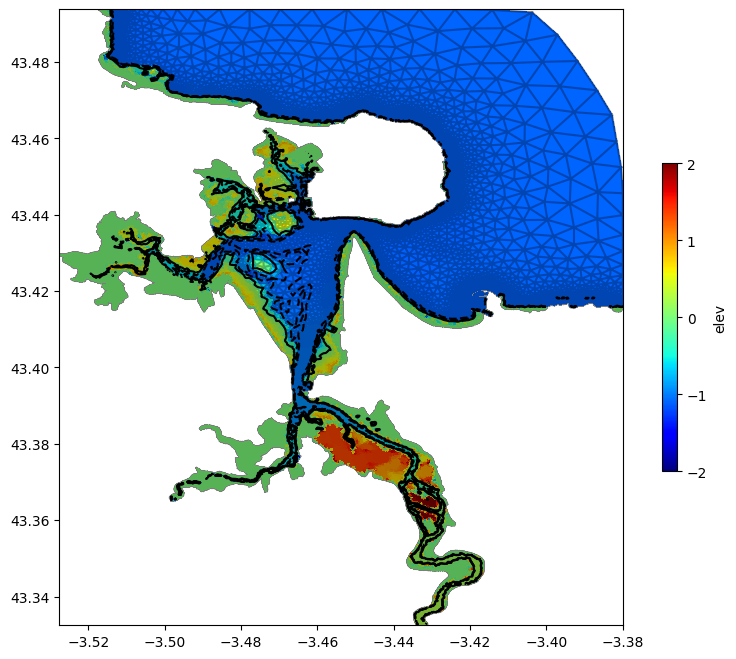

In [ ]:
schism_plot(schout, meshtri, 'elev', time=tiempo[186], project=False, plotmesh=True, mask=True, contours=[0, 1, 2], varscale=[-2, 2])


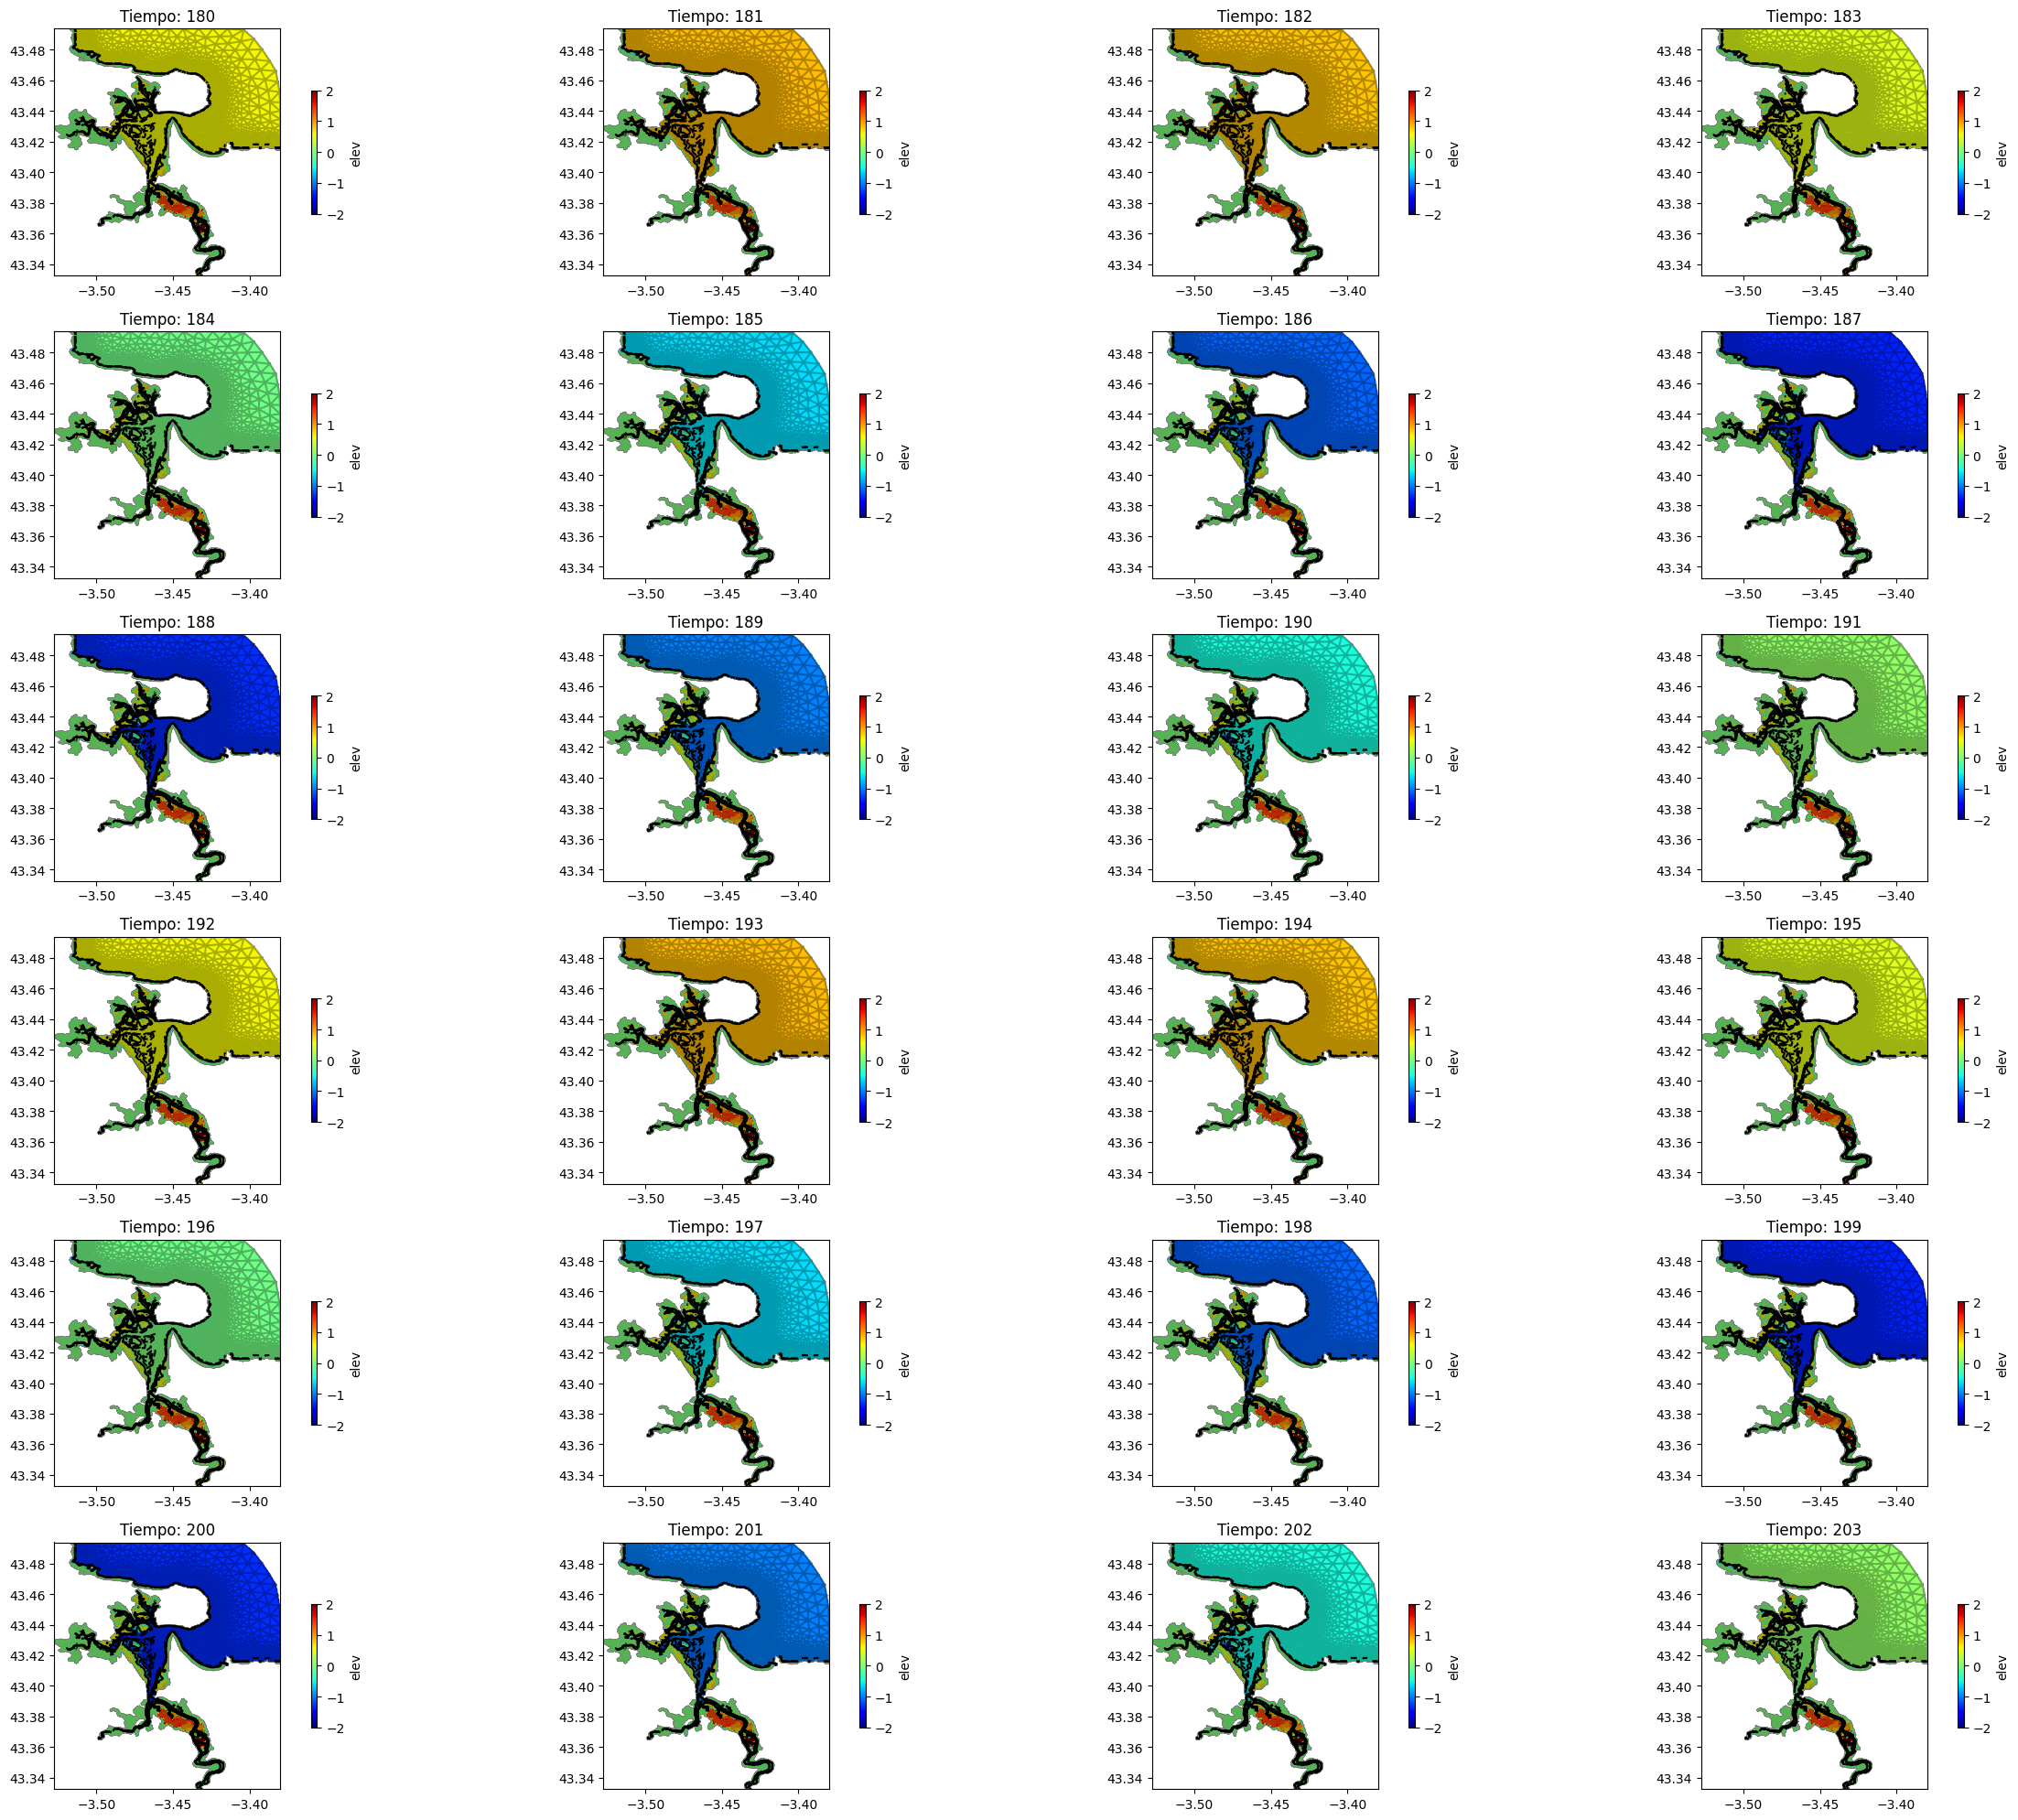

In [ ]:
#tiempos = [1, 2, 3, 4, 5, 6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

minimo = 180
maximo = 210
tiempos = list(range(minimo, maximo+1))

# Crear una matriz de subgráficos de 6x4
fig, axs = plt.subplots(6, 4, figsize=(25, 20))

# Iterar sobre los tiempos y los subgráficos correspondientes
for tiempo, ax in zip(tiempos, axs.flatten()):
    # Llamar a schism_plot y mostrar el resultado en el subplot actual
    schism_plot(schout, meshtri, 'elev', time=tiempo, project=False, plotmesh=True, mask=True, contours=[0, 1, 2], varscale=[-2, 2], ax=ax)
    ax.set_title(f'Tiempo: {tiempo}')  # Agregar título con el tiempo

# Ajustar el diseño y mostrar la figura
plt.tight_layout()
plt.show()

In [ ]:
import xarray as xr
import numpy as np
from matplotlib.tri import Triangulation


In [ ]:
# load file
name_case_1 = "0000"
schfile_1 = "/home/grupos/geocean/perezdb/lopezsi/Santona_metamodel_23052024/test_Santona_metamodel/Case_test_1_wind/outputs/schout_1.nc"
schout_1, meshtri_1 = schism_load(schfile_1)

In [ ]:
# assign to lons and lats
lons = schout_1.SCHISM_hgrid_node_x.values
lats = schout_1.SCHISM_hgrid_node_y.values

In [ ]:
schout_1

<xarray.Dataset> Size: 290MB
Dimensions:                  (time: 211, one: 1, nSCHISM_hgrid_face: 36970,
                              nMaxSCHISM_hgrid_face_nodes: 4,
                              nSCHISM_hgrid_edge: 57439, two: 2,
                              nSCHISM_hgrid_node: 20435, sigma: 2,
                              nSCHISM_vgrid_layers: 2)
Coordinates:
  * time                     (time) datetime64[ns] 2kB 2000-02-01T09:00:00 .....
  * sigma                    (sigma) float32 8B -1.0 0.0
Dimensions without coordinates: one, nSCHISM_hgrid_face,
                                nMaxSCHISM_hgrid_face_nodes,
                                nSCHISM_hgrid_edge, two, nSCHISM_hgrid_node,
                                nSCHISM_vgrid_layers
Data variables: (12/29)
    SCHISM_hgrid             (one) int32 4B ...
    SCHISM_hgrid_face_nodes  (nSCHISM_hgrid_face, nMaxSCHISM_hgrid_face_nodes) float64 1MB ...
    SCHISM_hgrid_edge_nodes  (nSCHISM_hgrid_edge, two) int32 460kB ...
    SCHISM_hgrid_node_x      (nSCHISM_hgrid_node) float64 163kB -3.434 ... -3...
    SCHISM_hgrid_node_y      (nSCHISM_hgrid_node) float64 163kB 43.33 ... 43.44
    node_bottom_index        (nSCHISM_hgrid_node) int32 82kB ...
    ...                       ...
    wetdry_side              (time, nSCHISM_hgrid_edge) float32 48MB ...
    zcor                     (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers) float32 34MB ...
    elev                     (time, nSCHISM_hgrid_node) float32 17MB ...
    wind_speed               (time, nSCHISM_hgrid_node, two) float32 34MB ...
    dahv                     (time, nSCHISM_hgrid_node, two) float32 34MB ...
    hvel                     (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers, two) float32 69MB ...
Attributes:
    Conventions:   CF-1.0, UGRID-1.0
    title:         SCHISM Model output
    institution:   SCHISM Model output
    source:        SCHISM model output version v10
    references:    http://ccrm.vims.edu/schismweb/
    history:       created by combine_output11
    comment:       SCHISM Model output
    type:          SCHISM Model output
    VisIT_plugin:  https://schism.water.ca.gov/library/-/document_library/vie...

In [ ]:
# # define image path
# path_image = './Google_Earth/VanKIRAP.png'

# # define corners
# x_left, x_rigth = 163.1, 172.1
# y_low, y_upper = -21.57, -12.6

# # load vanuatu background image
# im = plt.imread(path_image)

In [ ]:
# Define land
depth_mod = schout_1.depth.values
depth_mod[depth_mod > 0] = 0

In [ ]:
# Define the time of interest (according to the loaded schout)
date_schism = "2000-02-01T11:00:00.000000000"

In [ ]:
elev = schout_1.elev.sel(time=date_schism)  # v component


In [ ]:
# SCHISM current calculation
u = schout_1.dahv.sel(time=date_schism, two=0)  # u component
v = schout_1.dahv.sel(time=date_schism, two=1)  # v component

m = np.sqrt(u**2 + v**2)  # get current magnitude from u & v components
m  # check it out

<xarray.DataArray 'dahv' (nSCHISM_hgrid_node: 20435)> Size: 82kB
array([0.        , 0.        , 0.01350847, ..., 0.        , 0.        ,
       0.        ], shape=(20435,), dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2000-02-01T11:00:00
Dimensions without coordinates: nSCHISM_hgrid_node

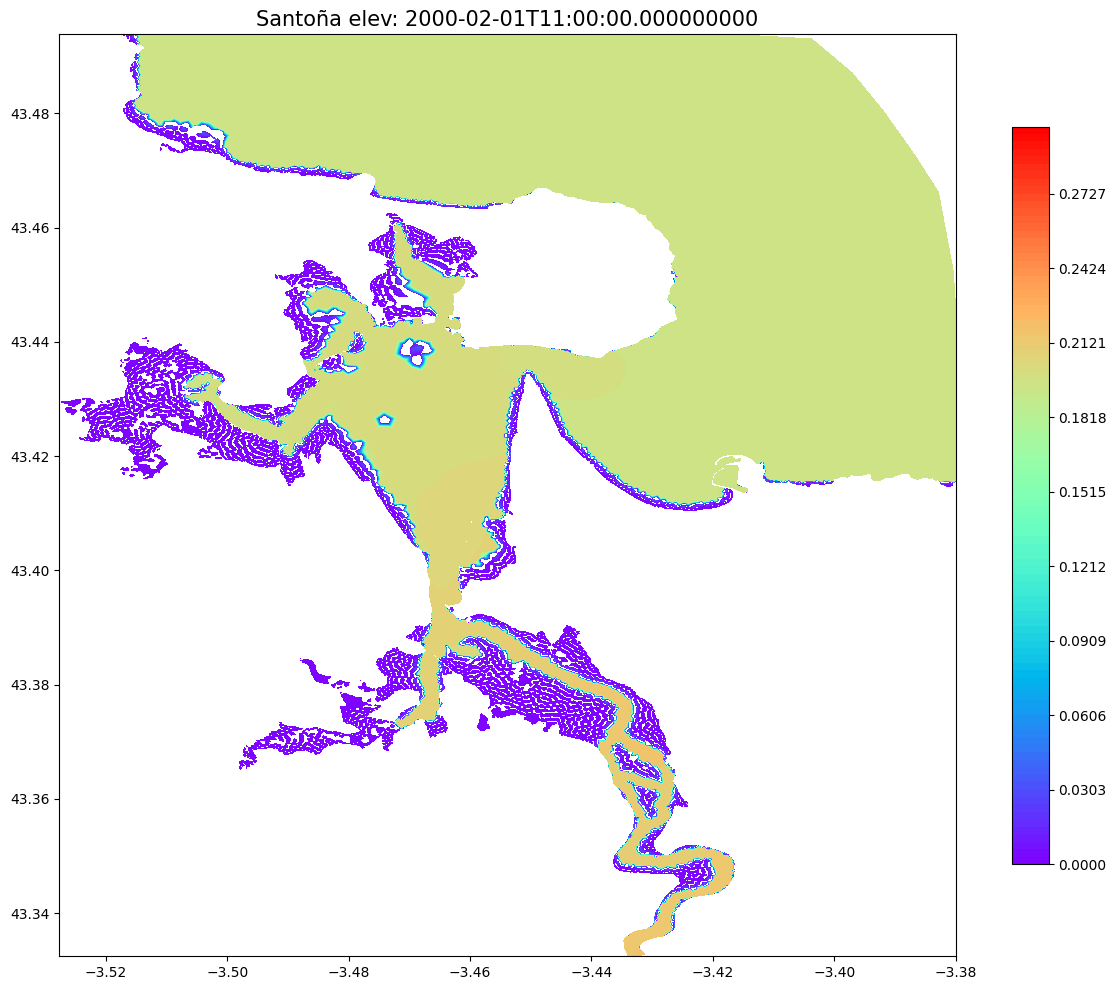

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))  # Un solo eje

# Contorno principal (currents)
cax_1 = ax.tricontourf(
    meshtri_1, elev, cmap="rainbow", vmin=0, vmax=0.3, levels=np.linspace(0, 0.3, 100)
)

# Barra de color
plt.colorbar(cax_1, ax=ax, shrink=0.8)

# Imagen de fondo
# ax.imshow(im, origin='upper', extent=[x_left, x_rigth, y_low, y_upper], aspect='equal', alpha=1)

# # Contorno para tierra/fondo
# ax.tricontourf(meshtri_1, depth_mod, cmap="summer", levels=0, linewidths=0.5)

# Título y ejes
ax.set_title("Santoña elev: " + str(date_schism), fontsize=15)
# ax.set_xlim(x_left, x_rigth)
# ax.set_ylim(y_low, y_upper)

plt.tight_layout()
plt.show()

/tmp/ipykernel_915229/1535129110.py:28: UserWarning: linewidths is ignored by contourf
  ax.tricontourf(meshtri_1, depth_mod, cmap="summer", levels=0, linewidths=0.5)


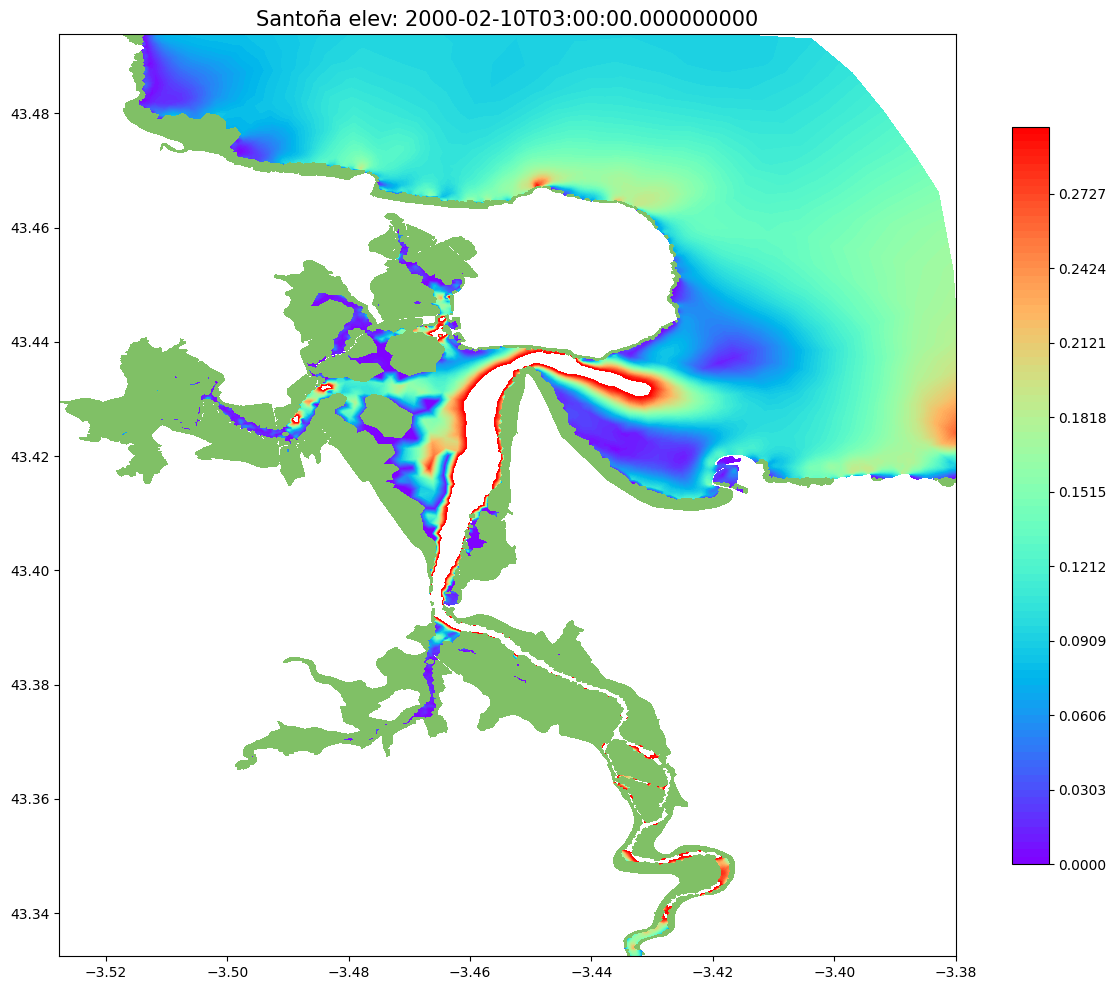

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))  # Un solo eje

# Contorno principal (currents)
cax_1 = ax.tricontourf(
    meshtri_1, m, cmap="rainbow", vmin=0, vmax=0.3, levels=np.linspace(0, 0.3, 100)
)
strm = ax.quiver(
    lons,
    lats,
    schout_1.dahv.sel(time=date_schism, two=0),
    schout_1.dahv.sel(time=date_schism, two=1),
    color="k",
    linewidth=20,
    scale=5,
    cmap="autumn",
)  # arrows

# Barra de color
plt.colorbar(cax_1, ax=ax, shrink=0.8)

# Imagen de fondo
# ax.imshow(im, origin='upper', extent=[x_left, x_rigth, y_low, y_upper], aspect='equal', alpha=1)

# Contorno para tierra/fondo
ax.tricontourf(meshtri_1, depth_mod, cmap="summer", levels=0, linewidths=0.5)

# Título y ejes
ax.set_title("Santoña elev: " + str(date_schism), fontsize=15)
# ax.set_xlim(x_left, x_rigth)
# ax.set_ylim(y_low, y_upper)

plt.tight_layout()
plt.show()
